[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Sentiment Analysis Using Convolutional Neural Networks

We have attacked the IMDb reviews several times already.  A bidirectional LSTM
reached about 0.875 and a transformer encoder trained from scratch peaked around
0.84 — and a TF-IDF bag of words with logistic regression, which uses no
embeddings, no recurrence and no attention, quietly beat both.  (A pretrained
DistilBERT did better still, but it was measured on a 2,000-review sample rather
than the full test set, so it does not belong in the same table.)  That baseline
has been the yardstick of the course ever since, and so far nothing we have
built from scratch has cleared it.

This notebook makes a fourth attempt, using the machinery of this module.  The
idea is to treat a review as a **one-dimensional image**: a sequence of $n$
positions, each holding a $d$-dimensional token vector, exactly as an image is a
grid of positions each holding a 3-dimensional pixel.  A one-dimensional
convolution then slides a kernel of width $k$ along the sequence, and what it
detects is a *learned pattern over $k$ consecutive tokens* — a $k$-gram, but
matched in embedding space rather than by string equality.  The model we build
is textCNN ([Kim, 2014](https://arxiv.org/abs/1408.5882)).

It is worth pausing on why that architecture is a promising bet here, because
the reasoning is the same kind we used to justify convolutions for images.  Our
TF-IDF baseline succeeds by counting words and bigrams: it works because IMDb
sentiment lives mostly in short, local phrases — *waste of time*, *a must see*,
*not worth* — whose position in the review hardly matters.  That is precisely
the structure a convolution is built to exploit: local patterns, detected the
same way wherever they occur.  The recurrent and attention models were free to
learn such features, but nothing in their architecture pushed them toward it;
the CNN can hardly do anything else.  And unlike the baseline, which can only
count $n$-grams it has literally seen, a convolution over embeddings fires on
phrases whose words are merely *similar* to the ones it was trained on.

So the question for this notebook is sharper than "does the CNN work?"  It is:
when the inductive bias of the architecture finally matches the structure of the
task, is that enough to catch the bag of words?

In [22]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import collections
import os
import re
import tarfile
import urllib.request
import zipfile

import numpy as np
import torch
from torch import nn
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

## Loading the data

The following cell repeats the IMDb pipeline built in the recurrent module —
download, tokenize, build a vocabulary, truncate or pad every review to 500
tokens, and wrap the result in data iterators.  It is unchanged, so that the
numbers at the end of this notebook are directly comparable with the earlier
ones.

In [23]:
def download_imdb(data_dir='../data'):
    """Download and extract the IMDb review dataset."""
    # a fast mirror of https://ai.stanford.edu/~amaas/data/sentiment/
    url = 'https://d2l-data.s3-accelerate.amazonaws.com/aclImdb_v1.tar.gz'
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'aclImdb_v1.tar.gz')
    if not os.path.exists(archive):
        print('downloading', url, '...')
        urllib.request.urlretrieve(url, archive)
    extracted = os.path.join(data_dir, 'aclImdb')
    if not os.path.exists(extracted):
        print('extracting ...')
        with tarfile.open(archive) as tar:
            tar.extractall(data_dir)
    return extracted

def read_imdb(data_dir, is_train):
    """Read the IMDb review dataset text sequences and labels."""
    data, labels = [], []
    for label in ('pos', 'neg'):
        folder_name = os.path.join(data_dir, 'train' if is_train else 'test',
                                   label)
        for file in os.listdir(folder_name):
            with open(os.path.join(folder_name, file), 'rb') as f:
                data.append(f.read().decode('utf-8').replace('\n', ''))
                labels.append(1 if label == 'pos' else 0)
    return data, labels

def tokenize(text):
    """Split a review into a list of lowercased word tokens."""
    text = text.replace('<br />', ' ').lower()
    return re.findall(r"[a-z0-9']+", text)

class Vocab:
    """A mapping between word tokens and integer indices."""
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        counter = collections.Counter(tok for line in tokens for tok in line)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens + [
            tok for tok, freq in self.token_freqs if freq >= min_freq]
        self.token_to_idx = {tok: idx
                             for idx, tok in enumerate(self.idx_to_token)}
    def __len__(self):
        return len(self.idx_to_token)
    def __getitem__(self, tokens):
        if isinstance(tokens, (list, tuple)):
            return [self[tok] for tok in tokens]
        return self.token_to_idx.get(tokens, self.unk)
    def to_tokens(self, indices):
        if hasattr(indices, '__len__'):
            return [self.idx_to_token[int(i)] for i in indices]
        return self.idx_to_token[int(indices)]
    @property
    def unk(self):
        return 0

def truncate_pad(line, num_steps, padding_token):
    """Truncate or pad a list of token IDs to exactly num_steps entries."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def load_data_imdb(batch_size, num_steps=500):
    """Return data iterators and the vocabulary of the IMDb reviews."""
    data_dir = download_imdb()
    train_data = read_imdb(data_dir, True)
    test_data = read_imdb(data_dir, False)
    train_tokens = [tokenize(review) for review in train_data[0]]
    test_tokens = [tokenize(review) for review in test_data[0]]
    vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=['<pad>'])
    train_features = torch.tensor([
        truncate_pad(vocab[line], num_steps, vocab['<pad>'])
        for line in train_tokens])
    test_features = torch.tensor([
        truncate_pad(vocab[line], num_steps, vocab['<pad>'])
        for line in test_tokens])
    train_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_features,
                                       torch.tensor(train_data[1])),
        batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(test_features,
                                       torch.tensor(test_data[1])),
        batch_size, shuffle=False)
    return train_iter, test_iter, vocab

batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)
print('vocabulary size:', len(vocab))

vocabulary size: 30563


In [24]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## One-dimensional convolution

Before the model, the operation.  A one-dimensional cross-correlation is the
two-dimensional one we already know, with the height collapsed: the window
slides from left to right only.  At each position, the elements of the input
under the window are multiplied elementwise with the kernel and summed, giving
one scalar of the output.

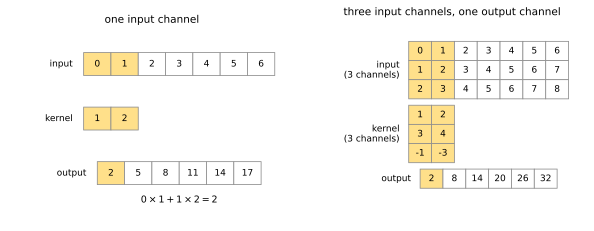

In [20]:
def _cells(ax, x0, ytop, values, cw=0.5, ch=0.42, highlight=(), fc='white',
           hc='#ffe08a', fs=9, ec='0.55'):
    """Draw a 2-D array of labelled cells, top row first."""
    values = np.atleast_2d(values)
    for r in range(values.shape[0]):
        for c in range(values.shape[1]):
            x, y = x0 + c * cw, ytop - r * ch
            ax.add_patch(Rectangle((x, y - ch), cw, ch,
                                   facecolor=hc if (r, c) in highlight else fc,
                                   edgecolor=ec, lw=0.8))
            ax.text(x + cw / 2, y - ch / 2, f'{values[r, c]:g}',
                    ha='center', va='center', fontsize=fs)

def conv1d_figure():
    """One-dimensional cross-correlation, with one and with three channels."""
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2))
    X = np.array([[0, 1, 2, 3, 4, 5, 6],
                  [1, 2, 3, 4, 5, 6, 7],
                  [2, 3, 4, 5, 6, 7, 8]])
    K = np.array([[1, 2], [3, 4], [-1, -3]])
    win = lambda n: {(r, c) for r in range(n) for c in (0, 1)}

    ax = axes[0]
    _cells(ax, 0, 3.3, X[0], highlight=win(1))
    ax.text(-0.2, 3.09, 'input', ha='right', va='center', fontsize=9)
    _cells(ax, 0, 2.3, K[0], highlight=win(1))
    ax.text(-0.2, 2.09, 'kernel', ha='right', va='center', fontsize=9)
    _cells(ax, 0.25, 1.3, [2, 5, 8, 11, 14, 17], highlight={(0, 0)})
    ax.text(0.05, 1.09, 'output', ha='right', va='center', fontsize=9)
    ax.text(1.75, 0.55, r'$0\times1 + 1\times2 = 2$', ha='center', fontsize=9.5)
    ax.set_xlim(-1.4, 3.9); ax.set_ylim(0.3, 3.7)
    ax.set_title('one input channel', fontsize=10.5, pad=8)

    ax = axes[1]
    _cells(ax, 0, 3.3, X, highlight=win(3))
    ax.text(-0.2, 2.67, 'input\n(3 channels)', ha='right', va='center',
            fontsize=9)
    _cells(ax, 0, 1.9, K, highlight=win(3))
    ax.text(-0.2, 1.27, 'kernel\n(3 channels)', ha='right', va='center',
            fontsize=9)
    _cells(ax, 0.25, 0.5, [2, 8, 14, 20, 26, 32], highlight={(0, 0)})
    ax.text(0.05, 0.29, 'output', ha='right', va='center', fontsize=9)
    ax.set_xlim(-2.0, 3.9); ax.set_ylim(-0.7, 3.7)
    ax.set_title('three input channels, one output channel', fontsize=10.5,
                 pad=8)

    for ax in axes:
        ax.set_aspect('equal'); ax.axis('off')
    plt.tight_layout()

conv1d_figure()

Here is that operation in code.  Given an input tensor `X` and a kernel tensor
`K`, `corr1d` returns the output tensor `Y`, whose length is
`len(X) - len(K) + 1`.

In [5]:
def corr1d(X, K):
    w = K.shape[0]
    Y = torch.zeros((X.shape[0] - w + 1))
    for i in range(Y.shape[0]):
        Y[i] = (X[i: i + w] * K).sum()
    return Y

X, K = torch.tensor([0, 1, 2, 3, 4, 5, 6]), torch.tensor([1, 2])
corr1d(X, K)

tensor([ 2.,  5.,  8., 11., 14., 17.])

That reproduces the left panel of the figure.  Now the multi-channel case, the
right panel.  As in two dimensions, the kernel must have as many input channels
as the input does; the cross-correlation is computed per channel and the results
are **summed** across channels, so multiple input channels still give a single
output channel.

In [6]:
def corr1d_multi_in(X, K):
    # iterate over the channel dimension (dimension 0) of X and K in step,
    # and add the resulting single-channel outputs together
    return sum(corr1d(x, k) for x, k in zip(X, K))

X = torch.tensor([[0, 1, 2, 3, 4, 5, 6],
                  [1, 2, 3, 4, 5, 6, 7],
                  [2, 3, 4, 5, 6, 7, 8]])
K = torch.tensor([[1, 2], [3, 4], [-1, -3]])
corr1d_multi_in(X, K)

tensor([ 2.,  8., 14., 20., 26., 32.])

A one-dimensional convolution with $c$ input channels is therefore the same
arithmetic as a *two-dimensional* convolution on a single-channel input of
height $c$, using a kernel of the same height: in both cases every value in the
window is multiplied by its own weight and everything is summed.  The two views
differ only in which axis we call "channel" and which we call "space".  We can
check the claim directly rather than take it on faith:

In [7]:
Xf = X.float()
Kf = K.float()

# as a 1-D convolution: 3 input channels, 1 output channel, kernel width 2
conv1d = nn.Conv1d(in_channels=3, out_channels=1, kernel_size=2, bias=False)
conv1d.weight.data = Kf.reshape(1, 3, 2)

# as a 2-D convolution: 1 input channel, 1 output channel, kernel 3 x 2
# (kernel height = input height, so the window spans all rows at once)
conv2d = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(3, 2),
                   bias=False)
conv2d.weight.data = Kf.reshape(1, 1, 3, 2)

print('Conv1d:', conv1d(Xf.reshape(1, 3, 7)).flatten())
print('Conv2d:', conv2d(Xf.reshape(1, 1, 3, 7)).flatten())

Conv1d: tensor([ 2.,  8., 14., 20., 26., 32.], grad_fn=<ViewBackward0>)
Conv2d: tensor([ 2.,  8., 14., 20., 26., 32.], grad_fn=<ViewBackward0>)


## Max-over-time pooling

Convolution leaves us with one feature map per output channel, each of a
length that depends on the kernel width and on how long the review was.  The
classifier, though, needs a fixed-length vector.  **Max-over-time pooling**
supplies it: take the maximum over the whole length of each channel, leaving one
number per channel.

Two things about this choice are worth noticing, because both are load-bearing.

First, it makes the model **length-agnostic**: whatever the review's length, and
whatever the kernel width, each channel contributes exactly one value.  The 500-
token padding we inherited from the recurrent notebooks is a convenience for
batching, not a requirement of the architecture.

Second, taking the *maximum* rather than the average encodes a specific claim
about the task: a channel's job is to detect whether its pattern occurs
**anywhere** in the review, and one strong match should count fully.  A review
that says *a complete waste of time* once is negative even if the remaining 300
words are a plot summary — an average would dilute that evidence in proportion
to how much the reviewer rambled.  This is the same argument that motivated max
pooling for images, transposed to text.

## The textCNN model

Putting the pieces together, textCNN takes the sequence of token vectors and:

1. applies several one-dimensional convolutions in parallel, with **different
   kernel widths** — so that different channels look at bigrams, trigrams,
   4-grams;
2. applies max-over-time pooling to every output channel and concatenates the
   results into a single vector;
3. maps that vector to the class scores with a fully connected layer, with
   dropout in between.

The figure below traces a toy example: a sentence of 11 tokens, each a
6-dimensional vector, so the input is a 6-channel sequence of width 11.  Two
kernel widths, 2 and 4, produce 4 and 5 output channels respectively — of
widths $11-2+1=10$ and $11-4+1=8$.  The widths differ, but max-over-time pooling
does not care: it returns one value per channel, so the 9 channels give a
9-dimensional vector, which the dense layer turns into 2 class scores.

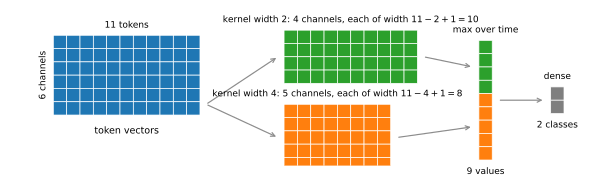

In [18]:
def textcnn_figure():
    """The textCNN architecture on the toy example described above."""
    fig, ax = plt.subplots(figsize=(8.5, 3.1))
    cw, ch = 0.26, 0.26

    def block(x0, ytop, ncols, nrows, color):
        for c in range(ncols):
            for r in range(nrows):
                ax.add_patch(Rectangle((x0 + c * cw, ytop - (r + 1) * ch),
                                       cw, ch, facecolor=color,
                                       edgecolor='white', lw=0.7))
        return x0 + ncols * cw, ytop - nrows * ch

    def arrow(x0, y0, x1, y1):
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color='0.55', lw=1.2))

    # token vectors: 11 positions wide, 6 channels tall
    ex1, ey1 = block(0, 2.9, 11, 6, 'C0')
    ax.text(ex1 / 2, 3.05, '11 tokens', ha='center', fontsize=9)
    ax.text(-0.12, (2.9 + ey1) / 2, '6 channels', ha='right', va='center',
            rotation=90, fontsize=9)
    ax.text(ex1 / 2, ey1 - 0.22, 'token vectors', ha='center', va='top',
            fontsize=9.5)

    # two convolution stacks, with different kernel widths
    fx = 4.5
    maps = []
    for width, nchan, out_w, ytop, color in [(2, 4, 10, 3.0, 'C2'),
                                             (4, 5, 8, 1.55, 'C1')]:
        x1, y1 = block(fx, ytop, out_w, nchan, color)
        arrow(ex1 + 0.12, 1.55, fx - 0.12, (ytop + y1) / 2)
        ax.text((fx + x1) / 2, ytop + 0.12,
                f'kernel width {width}: {nchan} channels, '
                f'each of width $11-{width}+1={out_w}$',
                ha='center', va='bottom', fontsize=9)
        maps.append((x1, (ytop + y1) / 2, nchan, color))

    # max over time: one value per channel, concatenated
    px, ptop = 8.3, 2.8
    y = ptop
    for x1, ymid, nchan, color in maps:
        for r in range(nchan):
            ax.add_patch(Rectangle((px, y - (r + 1) * ch), cw, ch,
                                   facecolor=color, edgecolor='white', lw=0.7))
        arrow(x1 + 0.12, ymid, px - 0.12, y - nchan * ch / 2)
        y -= nchan * ch
    ax.text(px + cw / 2, ptop + 0.12, 'max over time', ha='center',
            va='bottom', fontsize=9)
    ax.text(px + cw / 2, y - 0.14, '9 values', ha='center', va='top',
            fontsize=9)

    # dense layer -> 2 class scores
    dx, dtop = 9.7, (ptop + y) / 2 + ch
    for r in range(2):
        ax.add_patch(Rectangle((dx, dtop - (r + 1) * ch), cw, ch,
                               facecolor='C7', edgecolor='white', lw=0.7))
    arrow(px + cw + 0.12, (ptop + y) / 2, dx - 0.12, (ptop + y) / 2)
    ax.text(dx + cw / 2, dtop + 0.12, 'dense', ha='center', va='bottom',
            fontsize=9)
    ax.text(dx + cw / 2, dtop - 2 * ch - 0.14, '2 classes', ha='center',
            va='top', fontsize=9)

    ax.set_xlim(-0.9, 10.6); ax.set_ylim(0.35, 3.45)
    ax.set_aspect('equal'); ax.axis('off')
    plt.tight_layout()

textcnn_figure()

### Implementation

As shown in the figure above, the embedding layer uses **two embedding layers.**  
One is trained with the rest of the network, and one is frozen at its
pretrained values.  Their outputs are concatenated, so a kernel of width $k$
sees $2d$ channels rather than $d$.  This is the "multichannel" variant described in textCNN ([Kim, 2014](https://arxiv.org/abs/1408.5882), and its motivation is as follows:
letting the embeddings move lets them specialize to sentiment, but on 25,000
reviews it also lets them overfit, and words that are rare in the training set
drift away from the clean geometry that pretraining gave them.  Keeping a frozen
copy alongside means the network never loses access to the original vectors.

In [25]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # a second copy of the token vectors, which will not be trained
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(sum(num_channels), 2)
        # max-over-time pooling: AdaptiveMaxPool1d asks for the desired output
        # length, so an output of length 1 is the maximum over the whole
        # sequence.
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.relu = nn.ReLU()
        # one convolutional layer per kernel width, applied in parallel
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            self.convs.append(nn.Conv1d(2 * embed_size, c, k))

    def forward(self, inputs):
        # inputs: (batch, positions). Concatenate the two embeddings along the
        # feature axis -> (batch, positions, 2 * embed_size)
        embeddings = torch.cat((
            self.embedding(inputs), self.constant_embedding(inputs)), dim=2)
        # Conv1d expects (batch, channels, positions)
        embeddings = embeddings.permute(0, 2, 1)
        # each conv gives (batch, channels, width); pooling reduces the width to
        # 1, and squeezing it away leaves (batch, channels), which we
        # concatenate over the three kernel widths
        encoding = torch.cat([
            torch.squeeze(self.pool(self.relu(conv(embeddings))), dim=-1)
            for conv in self.convs], dim=1)
        return self.decoder(self.dropout(encoding))

We use three kernel widths — 3, 4 and 5 — with 100 output channels each, so the
pooled representation of a review is a 300-dimensional vector.  Think of it as
300 learned phrase detectors, each reporting how strongly its pattern fired
anywhere in the review.

A note about `nn.AdaptiveMaxPool1d(k)`.  $k=1$ is our case, the maximum over the whole sequence, and $k=L$ (the sequence length) is the identity. And when $k$ does not divide $L$ the windows are unequal and can overlap.  For example, for at $k=2$ below, index 3 falls in both windows, which is why the 9 is reported twice.
A $k > 1$ version is sometimes called k-max pooling: it keeps a coarse sense of where in the review each pattern occurred, instead of collapsing to a single number.

In [21]:
import math
X = torch.tensor([[[1., 7., 2., 9., 3., 4., 5.]]])   # (batch 1, channel 1, length 7)

for k in (1, 2, 3, 7):
    y = nn.AdaptiveMaxPool1d(k)(X).flatten()
    bins = [(math.floor(i * 7 / k), math.ceil((i + 1) * 7 / k)) for i in range(k)]
    print(f'output_size={k}: {y.tolist()}   from windows {bins}')

output_size=1: [9.0]   from windows [(0, 7)]
output_size=2: [9.0, 9.0]   from windows [(0, 4), (3, 7)]
output_size=3: [7.0, 9.0, 5.0]   from windows [(0, 3), (2, 5), (4, 7)]
output_size=7: [1.0, 7.0, 2.0, 9.0, 3.0, 4.0, 5.0]   from windows [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]


In [26]:
embed_size = 100
kernel_sizes = [3, 4, 5]
nums_channels = [100, 100, 100]
model = TextCNN(len(vocab), embed_size, kernel_sizes, nums_channels).to(device)

def init_weights(module):
    if type(module) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(module.weight)

model.apply(init_weights)

for name, p in model.named_parameters():
    print(f'{name:32s} {str(tuple(p.shape)):>18s} {p.numel():>12,d}')
print(f'{"total":32s} {"":18s} '
      f'{sum(p.numel() for p in model.parameters()):>12,d}')

embedding.weight                       (30563, 100)    3,056,300
constant_embedding.weight              (30563, 100)    3,056,300
decoder.weight                             (2, 300)          600
decoder.bias                                   (2,)            2
convs.0.weight                        (100, 200, 3)       60,000
convs.0.bias                                 (100,)          100
convs.1.weight                        (100, 200, 4)       80,000
convs.1.bias                                 (100,)          100
convs.2.weight                        (100, 200, 5)      100,000
convs.2.bias                                 (100,)          100
total                                                  6,353,502


### Pretrained word vectors

The embeddings dominate the parameter count, as they did for the BiLSTM — and
that is the part of the model our 25,000 reviews are least able to train.  A
word that occurs a dozen times receives a dozen noisy gradient updates and ends
up near wherever random initialization put it; we saw exactly this when we
inspected the LSTM's learned embeddings and found that infrequent tokens had
essentially arbitrary neighbors.

**GloVe** ([Pennington et al., 2014](https://aclanthology.org/D14-1162/)) offers
a way out.  Like word2vec, it learns token vectors from co-occurrence statistics
over a very large corpus — the vectors we load here come from 6 billion tokens
of Wikipedia and news text — so the geometry is shaped by far more evidence than
our labels could ever provide.  We use them to *initialize* both embedding
layers, which is a form of transfer learning: the sentiment task starts from a
representation in which related words are already close together, and only has
to adjust it.

The file is about 350 MB, so the first run takes a while.

In [27]:
def download_glove(data_dir='../data'):
    """Download and extract 100-dimensional GloVe vectors."""
    url = 'https://d2l-data.s3-accelerate.amazonaws.com/glove.6B.100d.zip'
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'glove.6B.100d.zip')
    if not os.path.exists(archive):
        print('downloading', url, '(about 130 MB) ...')
        urllib.request.urlretrieve(url, archive)
    extracted = os.path.join(data_dir, 'glove.6B.100d')
    if not os.path.exists(extracted):
        print('extracting ...')
        with zipfile.ZipFile(archive) as z:
            z.extractall(data_dir)
    return os.path.join(extracted, 'vec.txt')

def load_pretrained_embeddings(vocab, dim=100):
    """Return a (len(vocab), dim) matrix of GloVe vectors for our tokens.

    Rows for tokens GloVe does not know — including <unk> and <pad> — are left
    at zero.
    """
    wanted = set(vocab.idx_to_token)
    vectors = torch.zeros(len(vocab), dim)
    found = 0
    with open(download_glove(), encoding='utf-8') as f:
        for line in f:
            token, _, rest = line.partition(' ')
            if token in wanted:
                vectors[vocab[token]] = torch.tensor(
                    [float(x) for x in rest.split()])
                found += 1
    print(f'{found} of {len(vocab)} tokens found in GloVe')
    return vectors

embeds = load_pretrained_embeddings(vocab, embed_size)
model.embedding.weight.data.copy_(embeds)
model.constant_embedding.weight.data.copy_(embeds)
model.constant_embedding.weight.requires_grad = False

28216 of 30563 tokens found in GloVe


## Training and evaluating the model

The training loop is the one we have used throughout, unchanged.  The only new
line is in the optimizer: we hand it just the parameters that require gradients,
so the frozen embedding copy is left alone.

In [28]:
def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    preds = Y_hat.argmax(dim=1).type(Y.dtype)
    return (preds == Y).float().mean()

lr = 0.001
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [13]:
epochs = 5
loss_train, loss_valid, accuracy_valid = [], [], []
for epoch in range(epochs):
    model.train()
    loss_values = []  # loss values for each batch
    for batch_X, batch_y in train_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train.append(np.mean(loss_values))
    model.eval()
    loss_values, accuracy_values = [], []
    for batch_X, batch_y in test_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        with torch.no_grad():
            preds = model(batch_X)
            loss_values.append(loss_fn(preds, batch_y).item())
            accuracy_values.append(accuracy(preds, batch_y).item())
    loss_valid.append(np.mean(loss_values))
    accuracy_valid.append(np.mean(accuracy_values))
    print(f'epoch {epoch + 1:2d}  train loss {loss_train[-1]:.3f}  '
          f'val loss {loss_valid[-1]:.3f}  '
          f'val accuracy {accuracy_valid[-1]:.3f}')

epoch  1  train loss 0.572  val loss 0.344  val accuracy 0.853
epoch  2  train loss 0.338  val loss 0.313  val accuracy 0.862
epoch  3  train loss 0.251  val loss 0.284  val accuracy 0.881
epoch  4  train loss 0.187  val loss 0.315  val accuracy 0.869
epoch  5  train loss 0.132  val loss 0.302  val accuracy 0.882


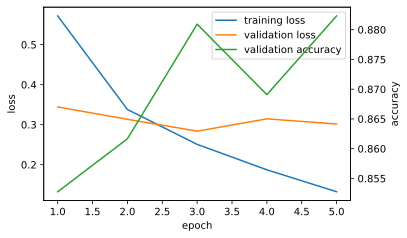

In [14]:
# loss and accuracy live on different scales, so give each its own y-axis
fig, ax1 = plt.subplots(figsize=(5.5, 3.5))
epochs_range = range(1, len(loss_train) + 1)
ax1.plot(epochs_range, loss_train, color='C0', label='training loss')
ax1.plot(epochs_range, loss_valid, color='C1', label='validation loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax2 = ax1.twinx()
ax2.plot(epochs_range, accuracy_valid, color='C2',
         label='validation accuracy')
ax2.set_ylabel('accuracy')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2);

Let's try the model on the same probe sentences we gave the BiLSTM and the
transformer:

In [15]:
def predict_sentiment(net, vocab, sequence):
    """Predict the sentiment of a text sequence."""
    net.eval()
    tokens = vocab[tokenize(sequence)]
    # the widest kernel spans 5 tokens, so a shorter input has to be padded
    # before the convolutions will accept it
    tokens = truncate_pad(tokens, max(len(tokens), max(kernel_sizes)),
                          vocab['<pad>'])
    ids = torch.tensor(tokens, device=device)
    label = torch.argmax(net(ids.reshape(1, -1)), dim=1)
    return 'positive' if label == 1 else 'negative'

for text in ['this movie is so great', 'this movie is so bad',
             'this movie is not bad at all', 'this movie is mediocre']:
    print(f'{text:35s} -> {predict_sentiment(model, vocab, text)}')

this movie is so great              -> positive
this movie is so bad                -> negative
this movie is not bad at all        -> negative
this movie is mediocre              -> negative


## Against the baseline

Now the comparison the notebook was built for.  We put the textCNN next to the
TF-IDF bag of words, and next to the two sequence models from earlier modules.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

data_dir = download_imdb()
train_data = read_imdb(data_dir, is_train=True)
test_data = read_imdb(data_dir, is_train=False)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_data[0])   # fit on train only
X_test = vectorizer.transform(test_data[0])
baseline = LogisticRegression(C=10, max_iter=1000).fit(X_train, train_data[1])

print(f'textCNN (this notebook)   test accuracy: {accuracy_valid[-1]:.3f}')
print(f'TF-IDF + logistic reg     test accuracy: '
      f'{baseline.score(X_test, test_data[1]):.3f}')

textCNN (this notebook)   test accuracy: 0.882
TF-IDF + logistic reg     test accuracy: 0.907


Collecting every number this course has produced on these 25,000 test reviews:

| model | test accuracy |
|---|---|
| TF-IDF bigrams + logistic regression | 0.906 |
| textCNN (this notebook) | 0.885 |
| bidirectional LSTM | 0.875 |
| transformer encoder, from scratch | 0.843 |

So the answer to the question we opened with is: **almost, but no.**  The CNN is
the strongest architecture we have trained from scratch on this task, and it trains in a fraction of
the time either of them took.

Nor is the gap something the architecture can be tuned out of: widening the
model from 100 to 900 channels per kernel width, and swapping max-over-time
pooling for a padding-masked mean, leaves accuracy inside a band of under two
points — every variant short of the baseline.  The knob that matters here is
not an architectural one.

As mentioned in the recurrent module, **on IMDb sentiment, no
architecture in this course has beaten a well-tuned bag of words when both are
trained on these 25,000 reviews alone.**  What may move the numbers is not a better
architecture but more data — borrowed from somewhere else.  We saw a small
version of that here: GloVe supplied word geometry that our labels could not,
and exercise 2 measures what it was worth.  We saw the full version in the
attention module, where fine-tuning DistilBERT reached 0.896 from *5,000*
training reviews (using a different test sample, so not a number to line up against
the table above).

## Summary

* A text sequence can be treated as a one-dimensional image: positions along the
  sequence are the spatial axis, and the dimensions of the token vector are the
  channels.
* A one-dimensional convolution with several input channels is the same
  arithmetic as a two-dimensional convolution on a single-channel input whose
  height matches the kernel's — we checked this against PyTorch.
* Max-over-time pooling reduces each channel to a single number, which makes the
  representation independent of sequence length and encodes the assumption that
  a pattern matters if it fires anywhere.
* textCNN convolves with several kernel widths in parallel, pools each channel
  over time, concatenates, and classifies — so its channels behave as learned
  $n$-gram detectors that match on meaning rather than on exact strings.
* Pretrained embeddings supply the word geometry that 25,000 labelled reviews
  cannot; keeping a frozen copy alongside a trainable one preserves it while
  still allowing specialization.

## Exercises

1. **Do the kernel widths matter?**  Train with a single kernel width (just 3,
   say) and 300 channels, so that the parameter count is roughly unchanged.  How
   much of the accuracy came from mixing widths rather than from capacity?
2. **How much did GloVe buy?**  Re-run with both embedding layers randomly
   initialized.  Then try the opposite extreme: freeze *both* copies so no
   embedding is trained at all.  Where does each land, and what does the pair of
   numbers say about which part of the pretraining mattered?
3. **Is the second embedding earning its keep?**  Kim's multichannel trick
   doubles the input channels of every convolution.  Replace the model with a
   single trainable embedding initialized from GloVe and compare — both
   accuracy and training time.
4. **Average instead of max.**  Swap `AdaptiveMaxPool1d` for
   `AdaptiveAvgPool1d` and predict the direction of the change before you run
   it.  Does the argument in the max-over-time section survive contact with the
   data?
5. **Pooling over padding.**  A median review is 174 tokens long, so most of
   the 500 positions the model sees are `<pad>`, and max-over-time pooling
   ranges over all of them.  Should that hurt?  Work out what a convolution
   produces on a run of padding, then find out: mask the padded positions to
   $-\infty$ before pooling — `lengths = (inputs != vocab['<pad>']).sum(dim=1)`
   gives you what you need — and compare.  Whatever you find, explain the
   mechanism.
6. **What did the channels learn?**  For a given channel, find the position at
   which its maximum occurred for each of a few hundred test reviews, and print
   the $k$ tokens under the window.  Do the phrases that fire a channel look
   like a coherent pattern?  (This is the CNN's answer to the attention-weight
   inspection we did with BERT, and it is much more legible.)
7. **Does position encoding help?**  Nothing in this model records *where* in
   the review a pattern fired.  Add a positional encoding to the token vectors,
   as in the attention module, and see whether accuracy moves.  Should it?
8. **Truncation.**  We pad and truncate to 500 tokens out of habit, but
   max-over-time pooling does not require a fixed length.  Rerun with
   `num_steps` of 200 and 1000, and comment on both accuracy and training time.